In [1]:
import json
from pathlib import Path

import h5py
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

%matplotlib inline
plt.style.use('./graph_preset.mplstyle')


In [15]:
read_path = Path("./0320104525_gp10/results.h5")

def load_h5_datasets(h5_path):
    datasets = {}

    def store_dataset(name, obj):
        if not isinstance(obj, h5py.Dataset):
            return

        print(f"  Loading: {name} | Shape: {obj.shape}")

        columns_attr = obj.attrs.get("columns")
        if isinstance(columns_attr, (bytes, np.bytes_)):
            columns_attr = columns_attr.decode("utf-8")
        columns = json.loads(columns_attr) if columns_attr is not None else None

        data = obj[:]
        datasets[name] = pd.DataFrame(data, columns=columns)

    with h5py.File(h5_path, "r") as f:
        print(f"--- Loading all datasets from {h5_path} ---")
        f.visititems(store_dataset)
        print("---------------------------------------------")

    return datasets


df_GP_JPS = load_h5_datasets(read_path)

print("\n--- Dictionary Keys ---")
print(list(df_GP_JPS.keys()))
print("-----------------------")


--- Loading all datasets from 0320104525_gp10\results.h5 ---
  Loading: output/repeat_1 | Shape: (50, 12)
  Loading: output/repeat_10 | Shape: (50, 12)
  Loading: output/repeat_2 | Shape: (50, 12)
  Loading: output/repeat_3 | Shape: (50, 12)
  Loading: output/repeat_4 | Shape: (50, 12)
  Loading: output/repeat_5 | Shape: (50, 12)
  Loading: output/repeat_6 | Shape: (50, 12)
  Loading: output/repeat_7 | Shape: (50, 12)
  Loading: output/repeat_8 | Shape: (50, 12)
  Loading: output/repeat_9 | Shape: (50, 12)
---------------------------------------------

--- Dictionary Keys ---
['output/repeat_1', 'output/repeat_10', 'output/repeat_2', 'output/repeat_3', 'output/repeat_4', 'output/repeat_5', 'output/repeat_6', 'output/repeat_7', 'output/repeat_8', 'output/repeat_9']
-----------------------


In [16]:
def merge_dataset_dicts(*dataset_dicts, start_index=1, key_template="output/repeat_{index}"):
    merged = {}
    next_index = start_index

    for dataset_dict in dataset_dicts:
        for _, df in sorted(dataset_dict.items()):
            merged[key_template.format(index=next_index)] = df.reset_index(drop=True).copy()
            next_index += 1

    return merged


def save_h5_datasets(dataset_dict, h5_path):
    h5_path = Path(h5_path)
    h5_path.parent.mkdir(parents=True, exist_ok=True)

    with h5py.File(h5_path, "w") as f:
        for name, df in sorted(dataset_dict.items()):
            dataset = f.create_dataset(name, data=df.to_numpy())
            dataset.attrs["columns"] = json.dumps([str(col) for col in df.columns])

    print(f"Saved {len(dataset_dict)} datasets to {h5_path}")


df_GP1 = load_h5_datasets(Path("./0412102126_gp_5/results.h5"))
df_GP2 = load_h5_datasets(Path("./0413191156_gp_5/results.h5"))
df_GP = merge_dataset_dicts(df_GP1, df_GP2)

--- Loading all datasets from 0412102126_gp_5\results.h5 ---
  Loading: output/repeat_1 | Shape: (100, 18)
  Loading: output/repeat_2 | Shape: (100, 18)
  Loading: output/repeat_3 | Shape: (100, 18)
  Loading: output/repeat_4 | Shape: (100, 18)
  Loading: output/repeat_5 | Shape: (100, 18)
---------------------------------------------
--- Loading all datasets from 0413191156_gp_5\results.h5 ---
  Loading: output/repeat_1 | Shape: (100, 18)
  Loading: output/repeat_2 | Shape: (100, 18)
  Loading: output/repeat_3 | Shape: (100, 18)
  Loading: output/repeat_4 | Shape: (100, 18)
  Loading: output/repeat_5 | Shape: (100, 18)
---------------------------------------------


Text(0, 0.5, 'S11 [dB]')

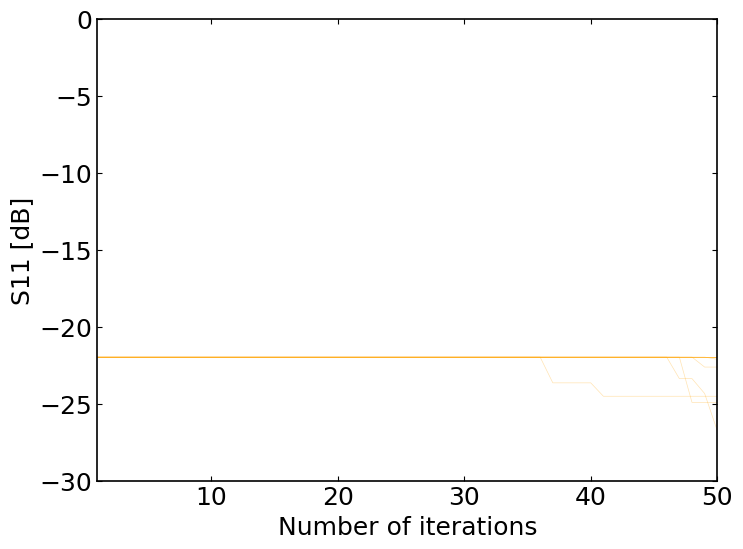

In [17]:
n_steps = 50
x = np.arange(1, n_steps + 1)

gp_runs = sorted(df_GP)

fig, ax = plt.subplots(1, 1, figsize=(8, 6), dpi=100)
for run_name in gp_runs:
    ax.plot(
        x,
        df_GP[run_name]["best"].iloc[:n_steps],
        alpha=0.3,
        color="orange",
        lw=0.5,
    )

ax.set_xlim(1, n_steps)
ax.set_ylim(-30, 0)
ax.set_xlabel("Number of iterations")
ax.set_ylabel("S11 [dB]")


In [18]:
df_GP['output/repeat_1']

,h1,h2,h3,h4,h5,s1,s2,s3,s4,s5,a,b,k,S11,Metric,gamma,routine_idx,best
0,5.000000,1.503409,2.285533,2.441034,4.919906,0.000000,1.500000,1.500000,1.500000,1.500000,2.000000,3.627538,6.000000,-21.980181,NaN,NaN,0.0,-21.980181
1,6.158415,6.858054,4.620418,4.735281,1.528618,1.064120,1.858115,1.106539,1.928465,1.549698,3.234841,4.443149,1.463306,-0.411902,NaN,NaN,0.0,-21.980181
2,6.553138,4.866699,3.651778,3.338616,4.001488,1.944303,0.692040,0.715748,0.998146,1.112635,4.383010,4.049295,2.732860,-3.453598,NaN,NaN,0.0,-21.980181
3,3.466180,9.114681,8.008556,4.054248,6.442542,1.223039,0.478858,0.005966,0.616443,0.491679,6.760110,3.418266,2.502305,-6.139786,NaN,NaN,0.0,-21.980181
4,2.531087,2.839532,5.097915,9.844165,5.177135,1.406941,1.330644,1.199846,0.402838,0.285060,2.924736,7.831467,5.321356,-2.185765,NaN,NaN,0.0,-21.980181
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,6.073720,1.000000,1.000000,1.000000,1.000000,1.000000,1.221982,0.000000,0.000000,2.000000,2.000000,3.732229,6.000000,-27.052223,NaN,11.481263,76.0,-27.666344
96,6.090902,1.000000,1.000000,1.000000,1.000000,1.000000,1.150686,2.000000,0.000000,2.000000,2.000000,3.743151,6.000000,-27.498968,NaN,9.517462,77.0,-27.666344
97,6.097115,1.000000,1.000000,1.000000,1.000000,1.000000,1.106559,2.000000,0.000000,2.000000,2.000000,3.742902,6.000000,-22.451469,NaN,8.469232,78.0,-27.666344
98,6.068655,1.000000,1.000000,1.000000,1.000000,1.000000,1.257967,0.000000,0.000000,2.000000,2.000000,3.721360,6.000000,-25.645771,NaN,11.466349,79.0,-27.666344


In [19]:
def _series_padded(df, column, n_steps=50):
    # Convert a column to a fixed-length numpy array for run-wise comparisons.
    values = pd.to_numeric(df[column], errors="coerce").to_numpy(dtype=float)
    if len(values) >= n_steps:
        return values[:n_steps]
    return np.pad(values, (0, n_steps - len(values)), mode="edge")


def _raw_matrix(dataset_dict, column, n_steps=50):
    # Stack all runs into a matrix with shape (n_runs, n_steps).
    run_names = sorted(dataset_dict)
    return np.vstack([_series_padded(dataset_dict[run_name], column, n_steps) for run_name in run_names])


def _best_so_far_matrix(dataset_dict, column, n_steps=50):
    raw_matrix = _raw_matrix(dataset_dict, column, n_steps)
    return np.minimum.accumulate(raw_matrix, axis=1)


def _median_iqr(matrix):
    # Compute the median and interquartile range at each iteration.
    median = np.nanmedian(matrix, axis=0)
    q25 = np.nanpercentile(matrix, 25, axis=0)
    q75 = np.nanpercentile(matrix, 75, axis=0)
    return median, q25, q75


def _final_best_values(dataset_dict, column):
    return np.array([
        pd.to_numeric(dataset_dict[run_name][column], errors="coerce").min()
        for run_name in sorted(dataset_dict)
    ])


def _plot_median_iqr(ax, x, matrix, color, label):
    median, q25, q75 = _median_iqr(matrix)
    ax.fill_between(x, q25, q75, color=color, alpha=0.15, linewidth=0)
    ax.plot(x, median, color=color, lw=2, label=label)
    ax.plot(x, q25, color=color, lw=1, ls="--", alpha=0.6)
    ax.plot(x, q75, color=color, lw=1, ls="--", alpha=0.6)


def _style_boxplot(boxplot, labels, colors):
    for patch, label in zip(boxplot["boxes"], labels):
        box_color = colors[label]
        patch.set(facecolor=box_color, alpha=0.30, edgecolor=box_color, linewidth=1.2)
    for median, label in zip(boxplot["medians"], labels):
        median.set(color=colors[label], linewidth=2)

    whisker_colors = [colors[label] for label in labels for _ in (0, 1)]
    for whisker, color in zip(boxplot["whiskers"], whisker_colors):
        whisker.set(color=color, linewidth=1.2)
    for cap, color in zip(boxplot["caps"], whisker_colors):
        cap.set(color=color, linewidth=1.2)


C:\Users\Suzuki Lab 10\AppData\Local\Temp\ipykernel_83960\316841092.py:44: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = ax1.boxplot(


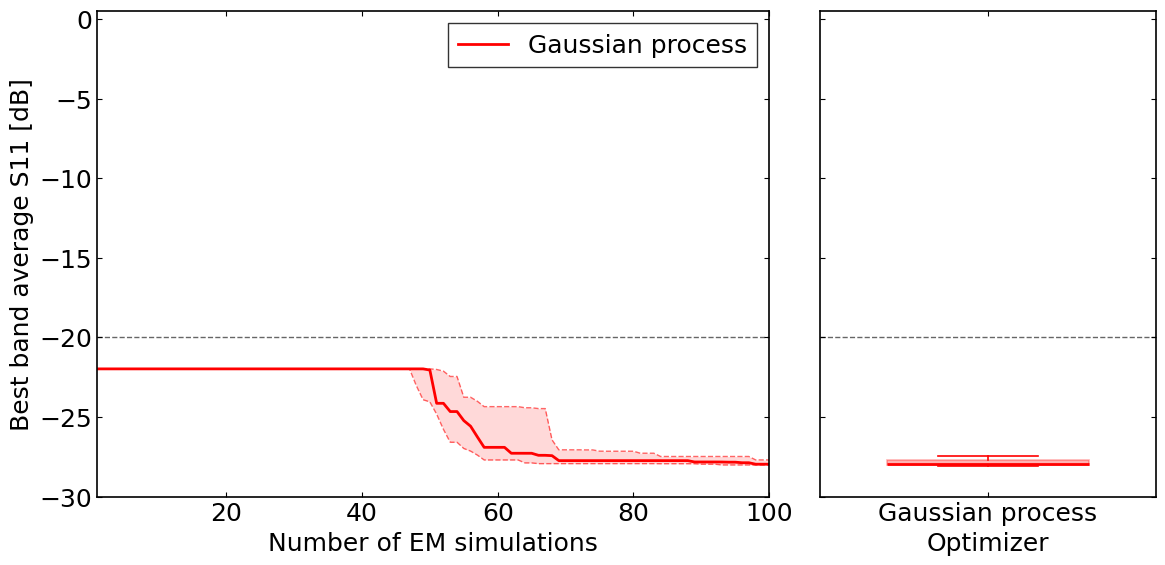

In [ ]:
n_steps = 100
x = np.arange(1, n_steps + 1)
colors = {
    "GP_new": "r",
    "GP_JPS": "b",
}

plot_targets = [
    {
        "label": "Gaussian process",
        "runs": df_GP,
        "column": "best",
        "color": colors["Gaussian process"],
    },
]

fig, (ax0, ax1) = plt.subplots(
    1,
    2,
    figsize=(12, 6),
    dpi=100,
    sharey=True,
    gridspec_kw={"width_ratios": [2, 1]},
)
fig.subplots_adjust(wspace=0)

final_values = []
labels = []
for target in plot_targets:
    best_so_far = _best_so_far_matrix(target["runs"], target["column"], n_steps=n_steps)
    _plot_median_iqr(ax0, x, best_so_far, target["color"], target["label"])

    final_values.append(_final_best_values(target["runs"], target["column"]))
    labels.append(target["label"])

for ax in (ax0, ax1):
    ax.axhline(-20, ls="--", lw=1, color="k", alpha=0.6)

ax0.set_xlim(1, n_steps)
ax0.set_ylim(-30, 0.5)
ax0.set_xlabel("Number of EM simulations")
ax0.set_ylabel("Best band average S11 [dB]")
ax0.legend(loc="upper right", frameon=True)

box = ax1.boxplot(
    final_values,
    labels=labels,
    vert=True,
    patch_artist=True,
    widths=0.6,
    showfliers=False,
)
_style_boxplot(box, labels, colors)

ax1.set_xlabel("Optimizer")
plt.tight_layout()


In [13]:
gp_best_id, gp_best_df = min(df_GP.items(), key=lambda kv: kv[1]['S11'].min())

In [14]:
gp_best_df.iloc[gp_best_df['S11'].idxmin()]

h1               6.225785
h2               4.065235
h3               9.188137
h4               9.788713
h5               1.000000
s1               1.071733
s2               2.000000
s3               1.456739
s4               1.835538
s5               0.537034
a                2.000000
b                3.711260
k                6.000000
S11            -29.529060
Metric                NaN
gamma          178.665283
routine_idx     68.000000
best           -29.529060
Name: 87, dtype: float32

In [ ]:
df_init = pd.read_csv("./SavedShapes/GP_init.csv",
                      names=["freq", "S11"],
                      skiprows=1,
                      )

df_GP_optim = pd.read_csv("./SavedShapes/GP.csv",
                          names=["freq", "S11"],
                            skiprows=1,
                        )

df_init.head(5)

,freq,S11
0,10.0,-10.824242
1,10.1,-11.035408
2,10.2,-11.236257
3,10.3,-11.427251
4,10.4,-11.608793


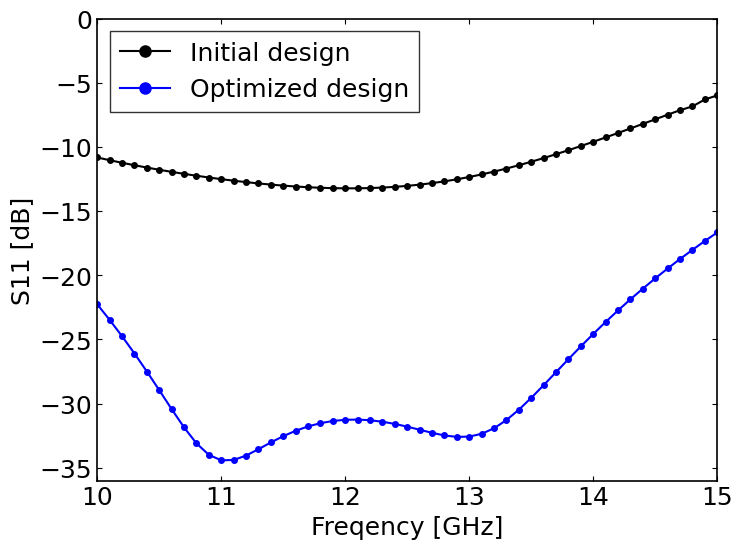

In [26]:
fig, ax = plt.subplots(1, 1, figsize=(8, 6), dpi=100)

ax.plot(df_init['freq'], df_init['S11'], label='Initial design', color='k', linestyle='-', marker='o', markersize=4)
ax.plot(df_GP_optim['freq'], df_GP_optim['S11'], label='Optimized design', color='b', linestyle='-', marker='o', markersize=4)


ax.set_ylim(-36, 0)
ax.set_xlim(10, 15)

ax.set_xlabel("Freqency [GHz]")
ax.set_ylabel("S11 [dB]")
ax.legend()


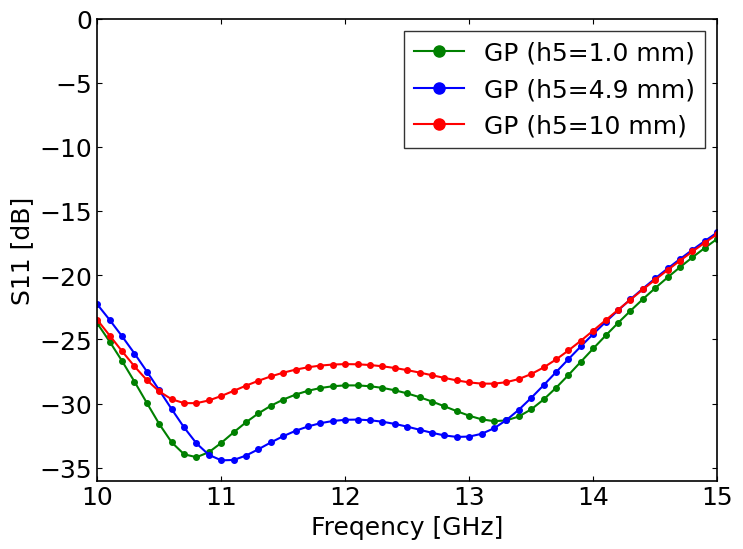

In [33]:
fig, ax = plt.subplots(1, 1, figsize=(8, 6), dpi=100)

ax.plot(df_GP_optim_1mm['freq'], df_GP_optim_1mm['S11'], label='GP (h5=1.0 mm)', color='g', linestyle='-', marker='o', markersize=4)
ax.plot(df_GP_optim['freq'], df_GP_optim['S11'], label='GP (h5=4.9 mm)', color='b', linestyle='-', marker='o', markersize=4)
ax.plot(df_GP_optim_10mm['freq'], df_GP_optim_10mm['S11'], label='GP (h5=10 mm)', color='r', linestyle='-', marker='o', markersize=4)


ax.set_ylim(-36, 0)
ax.set_xlim(10, 15)

ax.set_xlabel("Freqency [GHz]")
ax.set_ylabel("S11 [dB]")
ax.legend()


In [27]:
# --- Function to calculate superellipse coordinates ---
def get_superellipse_points(c,d,n,):
    # Generate evenly spaced angles from 0 to pi (180 degrees)
    theta = np.linspace(0, np.pi, 100)
    
    # Calculate coordinates using parametric equations
    x = c * np.sign(np.cos(theta)) * np.abs(np.cos(theta))**(2/n)
    y = d * np.sign(np.sin(theta)) * np.abs(np.sin(theta))**(2/n)
    
    return x, y

# --- Define shapes to plot ---
# Define n value, number of top vertices, and title for each shape
shapes = [
    {"c": 3.676328, "d": 3.065019, "n": 4.27495, "label": "Initial design"},
    {"c": 2.0, "d": 3.627538, "n": 6.0, "label": "GP design"},
]

(np.float64(-4.0), np.float64(4.0), np.float64(-1.0), np.float64(7.0))

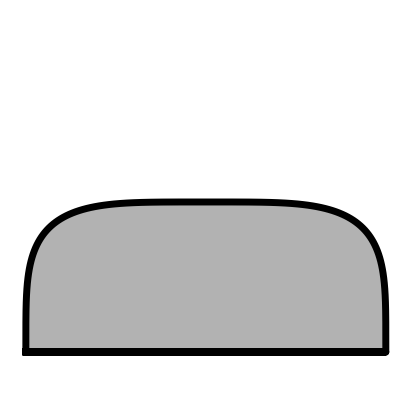

In [28]:
fig, ax = plt.subplots(1, 1, figsize=(4, 4), layout='constrained')
ax.set_box_aspect(1)
ax.set_aspect('equal', 'box')

c, d, n = shapes[0]['c'], shapes[0]['d'], shapes[0]['n']

# Calculate the vertices for the upper half of the superellipse
x_top, y_top = get_superellipse_points(c, d, n)

# Create the full list of vertices (add the two base points and close the shape)
x_coords = np.concatenate([[-c], x_top, [c], [-c]])
y_coords = np.concatenate([[0], y_top, [0], [0]])

# Plot the polygon
ax.plot(x_coords, y_coords, '-', lw=5, color='k', markersize=5)
ax.fill(x_coords, y_coords, color='k', alpha=0.3)

ax.set_xlim(-4, 4)
ax.set_ylim(-1, 7)
ax.set_xticklabels([])
ax.set_yticklabels([])
ax.axis('off')


(np.float64(-4.0), np.float64(4.0), np.float64(-1.0), np.float64(7.0))

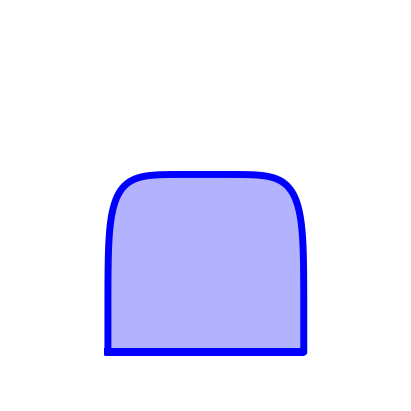

In [29]:
fig, ax = plt.subplots(1, 1, figsize=(4, 4), layout='constrained')
ax.set_box_aspect(1)
ax.set_aspect('equal', 'box')

c, d, n = shapes[1]['c'], shapes[1]['d'], shapes[1]['n']

# Calculate the vertices for the upper half of the superellipse
x_top, y_top = get_superellipse_points(c, d, n)

# Create the full list of vertices (add the two base points and close the shape)
x_coords = np.concatenate([[-c], x_top, [c], [-c]])
y_coords = np.concatenate([[0], y_top, [0], [0]])

# Plot the polygon
ax.plot(x_coords, y_coords, '-', lw=5, color='b', markersize=5)
ax.fill(x_coords, y_coords, color='b', alpha=0.3)

ax.set_xlim(-4, 4)
ax.set_ylim(-1, 7)
ax.set_xticklabels([])
ax.set_yticklabels([])
ax.axis('off')
